# Data Cleansing & Exploration

In [132]:
import pandas as pd
import math
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [133]:
original_df = pd.read_csv("/kaggle/input/isic-2024-skin-cancer-detection/train-metadata.csv")
original_df

/tmp/ipykernel_31/2857313565.py:1: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  original_df = pd.read_csv("/kaggle/input/isic-2024-skin-cancer-detection/train-metadata.csv")
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/l

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401054,ISIC_9999937,0,IP_1140263,70.0,male,anterior torso,6.80,TBP tile: close-up,3D: XP,22.574335,...,IL_9520694,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.999988
401055,ISIC_9999951,0,IP_5678181,60.0,male,posterior torso,3.11,TBP tile: close-up,3D: white,19.977640,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.999820
401056,ISIC_9999960,0,IP_0076153,65.0,female,anterior torso,2.05,TBP tile: close-up,3D: XP,17.332567,...,IL_9852274,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.999416
401057,ISIC_9999964,0,IP_5231513,30.0,female,anterior torso,2.80,TBP tile: close-up,3D: XP,22.288570,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,100.000000


In [134]:
original_df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510


In [135]:
import matplotlib.pyplot as plt

In [136]:
print(original_df.columns)

Index(['isic_id', 'target', 'patient_id', 'age_approx', 'sex',
       'anatom_site_general', 'clin_size_long_diam_mm', 'image_type',
       'tbp_tile_type', 'tbp_lv_A', 'tbp_lv_Aext', 'tbp_lv_B', 'tbp_lv_Bext',
       'tbp_lv_C', 'tbp_lv_Cext', 'tbp_lv_H', 'tbp_lv_Hext', 'tbp_lv_L',
       'tbp_lv_Lext', 'tbp_lv_areaMM2', 'tbp_lv_area_perim_ratio',
       'tbp_lv_color_std_mean', 'tbp_lv_deltaA', 'tbp_lv_deltaB',
       'tbp_lv_deltaL', 'tbp_lv_deltaLB', 'tbp_lv_deltaLBnorm',
       'tbp_lv_eccentricity', 'tbp_lv_location', 'tbp_lv_location_simple',
       'tbp_lv_minorAxisMM', 'tbp_lv_nevi_confidence', 'tbp_lv_norm_border',
       'tbp_lv_norm_color', 'tbp_lv_perimeterMM',
       'tbp_lv_radial_color_std_max', 'tbp_lv_stdL', 'tbp_lv_stdLExt',
       'tbp_lv_symm_2axis', 'tbp_lv_symm_2axis_angle', 'tbp_lv_x', 'tbp_lv_y',
       'tbp_lv_z', 'attribution', 'copyright_license', 'lesion_id',
       'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4', 'iddx_5',
       'mel_mitotic_index', '

In [137]:
original_df.shape
# Dataframe(rows, columns)

(401059, 55)

# data cleaning

In [138]:
original_df["mel_thick_mm"].unique()

array([ nan, 0.5 , 0.9 , 0.4 , 1.3 , 0.2 , 0.3 , 5.  , 2.5 , 0.35, 0.8 ,
       0.6 , 1.7 , 0.7 , 0.32, 0.55, 1.8 , 3.  , 1.4 , 0.45])

In [139]:
df = original_df[["isic_id","target","patient_id", "age_approx", "sex", "anatom_site_general", "image_type", "clin_size_long_diam_mm", "iddx_full", "iddx_1", "tbp_lv_dnn_lesion_confidence"  ]]

In [140]:
df.head()

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,image_type,clin_size_long_diam_mm,iddx_full,iddx_1,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,TBP tile: close-up,3.04,Benign,Benign,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,TBP tile: close-up,1.10,Benign,Benign,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,TBP tile: close-up,3.40,Benign,Benign,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,TBP tile: close-up,3.22,Benign,Benign,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,TBP tile: close-up,2.73,Benign,Benign,70.442510


In [141]:
df.shape

(401059, 11)

In [142]:
print(df['iddx_1'].unique())

['Benign' 'Malignant' 'Indeterminate']


In [143]:
#check for missing values 
missing_data = df.isnull().sum()
print(missing_data)

isic_id                             0
target                              0
patient_id                          0
age_approx                       2798
sex                             11517
anatom_site_general              5756
image_type                          0
clin_size_long_diam_mm              0
iddx_full                           0
iddx_1                              0
tbp_lv_dnn_lesion_confidence        0
dtype: int64


In [144]:
age_approx = df["age_approx"].unique()
print(age_approx)

[60. 65. 55. 75. 50. 70. 85. 45. 40. nan 30. 80. 35. 25. 15. 20.  5.]


**mean age of people with cancer = 58**

In [145]:
age_mean = df["age_approx"].mean()
age_mean = math.floor(age_mean)
df["age_approx"] = df["age_approx"].fillna(age_mean)
df["age_approx"].unique()

/tmp/ipykernel_31/532383519.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["age_approx"] = df["age_approx"].fillna(age_mean)


array([60., 65., 55., 75., 50., 70., 85., 45., 40., 58., 30., 80., 35.,
       25., 15., 20.,  5.])

In [146]:
df.shape

(401059, 11)

In [147]:
df['sex'].unique()
print(df['sex'].unique())
#print an array with all unique values in the sex column

['male' 'female' nan]


In [148]:
df = df[df["sex"].notna()]
#drop the row where the sex column has nan value
df["sex"].unique()

array(['male', 'female'], dtype=object)

In [149]:
df.shape

(389542, 11)

In [150]:
df['anatom_site_general'].unique()
print(df['anatom_site_general'].unique())
#print an array with all unique values in the column

['lower extremity' 'head/neck' 'posterior torso' 'anterior torso'
 'upper extremity' nan]


In [151]:
df = df[df["anatom_site_general"].notna()]
df["anatom_site_general"].unique()

array(['lower extremity', 'head/neck', 'posterior torso',
       'anterior torso', 'upper extremity'], dtype=object)

In [152]:
#check for missing values 
missing_data = df.isnull().sum()
print(missing_data)

isic_id                         0
target                          0
patient_id                      0
age_approx                      0
sex                             0
anatom_site_general             0
image_type                      0
clin_size_long_diam_mm          0
iddx_full                       0
iddx_1                          0
tbp_lv_dnn_lesion_confidence    0
dtype: int64


In [153]:
df.shape

(383794, 11)

In [154]:
# Rename the columns
df = df.rename(columns={
    "age_approx": "age",
    "iddx_full": "full_diagnosis", 
    "iddx_1": "first_diagnosis",
    "tbp_lv_dnn_lesion_confidence": "lesion_confidence_score",
    "clin_size_long_diam_mm": "lesion_diameter_mm"
})

In [155]:
skin_conditions_mapping = {
    # Benign conditions
    'Benign': [
        'Benign',
        'Benign::Benign epidermal proliferations::Lichen planus like keratosis',
        'Benign::Benign melanocytic proliferations::Nevus::Nevus, NOS, Junctional',
        'Benign::Benign melanocytic proliferations::Nevus',
        'Benign::Benign epidermal proliferations::Seborrheic keratosis',
        'Benign::Benign melanocytic proliferations::Nevus::Nevus, Atypical, Dysplastic, or Clark',
        'Benign::Benign melanocytic proliferations::Nevus::Nevus, NOS, Dermal',
        'Benign::Benign epidermal proliferations::Pigmented benign keratosis',
        'Benign::Benign epidermal proliferations::Solar lentigo',
        'Benign::Benign soft tissue proliferations - Fibro-histiocytic::Dermatofibroma',
        'Benign::Benign melanocytic proliferations::Nevus::Nevus, NOS, Compound',
        'Benign::Cysts::Trichilemmal or isthmic-catagen or pilar cyst',
        'Benign::Benign soft tissue proliferations - Fibro-histiocytic::Angiofibroma::Angiofibroma, Facial',
        'Benign::Benign soft tissue proliferations - Fibro-histiocytic::Scar',
        'Benign::Flat melanotic pigmentations - not melanocytic nevus::Lentigo NOS',
        'Benign::Benign melanocytic proliferations::Nevus::Nevus, Deep penetrating',
        'Benign::Benign melanocytic proliferations::Nevus::Nevus, Of special anatomic site',
        'Benign::Benign melanocytic proliferations::Nevus::Nevus, Spitz',
        'Benign::Inflammatory or infectious diseases::Verruca',
        'Benign::Benign melanocytic proliferations::Nevus::Nevus, Combined',
        'Benign::Benign melanocytic proliferations::Nevus::Blue nevus::Blue nevus, Cellular',
        'Benign::Benign melanocytic proliferations::Nevus::Nevus, Congenital',
        'Benign::Benign soft tissue proliferations - Vascular::Hemangioma::Hemangioma, Cherry',
        'Benign::Cysts',
        'Benign::Benign adnexal epithelial proliferations - Apocrine or Eccrine::Hidradenoma',
        'Benign::Benign soft tissue proliferations - Fibro-histiocytic::Fibroepithelial polyp',
        'Benign::Benign adnexal epithelial proliferations - Follicular',
        'Benign::Benign epidermal proliferations::Seborrheic keratosis::Seborrheic keratosis, Clonal'
    ],
    
    'Indeterminate': [
        'Indeterminate::Indeterminate epidermal proliferations::Solar or actinic keratosis',
        'Indeterminate::Indeterminate melanocytic proliferations::Atypical melanocytic neoplasm',
        'Indeterminate::Indeterminate epidermal proliferations::Solar or actinic keratosis::Actinic keratosis, Bowenoid',
        'Indeterminate::Indeterminate melanocytic proliferations::Atypical intraepithelial melanocytic proliferation'
    ],
    
    'Malignant': [
        'Malignant::Malignant epidermal proliferations::Squamous cell carcinoma in situ',
        'Malignant::Malignant adnexal epithelial proliferations - Follicular::Basal cell carcinoma::Basal cell carcinoma, Nodular',
        'Malignant::Malignant epidermal proliferations::Squamous cell carcinoma, Invasive',
        'Malignant::Malignant adnexal epithelial proliferations - Follicular::Basal cell carcinoma::Basal cell carcinoma, Superficial',
        'Malignant::Malignant melanocytic proliferations (Melanoma)::Melanoma in situ',
        'Malignant::Malignant melanocytic proliferations (Melanoma)::Melanoma in situ::Melanoma in situ, Lentigo maligna type',
        'Malignant::Malignant melanocytic proliferations (Melanoma)::Melanoma Invasive',
        'Malignant::Malignant melanocytic proliferations (Melanoma)::Melanoma, NOS',
        'Malignant::Malignant melanocytic proliferations (Melanoma)::Melanoma in situ::Melanoma in situ, associated with a nevus',
        'Malignant::Malignant adnexal epithelial proliferations - Follicular::Basal cell carcinoma::Basal cell carcinoma, Infiltrating',
        'Malignant::Malignant adnexal epithelial proliferations - Follicular::Basal cell carcinoma',
        'Malignant::Malignant melanocytic proliferations (Melanoma)::Melanoma Invasive::Melanoma Invasive, Superficial spreading',
        'Malignant::Malignant melanocytic proliferations (Melanoma)::Melanoma Invasive::Melanoma Invasive, Associated with a nevus',
        'Malignant::Malignant epidermal proliferations::Squamous cell carcinoma, Invasive::Squamous cell carcinoma, Invasive, Keratoacanthoma-type',
        'Malignant::Malignant melanocytic proliferations (Melanoma)::Melanoma metastasis',
        'Malignant::Malignant epidermal proliferations::Squamous cell carcinoma in situ::Squamous cell carcinoma in situ, Bowens disease',
        'Malignant::Malignant epidermal proliferations::Squamous cell carcinoma, NOS',
        'Malignant::Malignant melanocytic proliferations (Melanoma)::Melanoma Invasive::Melanoma Invasive, On chronically sun-exposed skin or lentigo maligna melanoma',
        'Malignant::Malignant melanocytic proliferations (Melanoma)::Melanoma in situ::Melanoma in situ, Superficial spreading',
        'Malignant::Malignant melanocytic proliferations (Melanoma)::Melanoma Invasive::Melanoma Invasive, Nodular'
    ]
}

def categorize_diagnosis(full_diagnosis):
    for category, diagnoses in skin_conditions_mapping.items():
        if full_diagnosis in diagnoses:
            return category
    
    if full_diagnosis.startswith('Benign'):
        return 'Benign'
    elif full_diagnosis.startswith('Malignant'):
        return 'Malignant'
    elif full_diagnosis.startswith('Indeterminate'):
        return 'Indeterminate'
    
    return 'Other'

df['malignancy_category'] = df['full_diagnosis'].apply(categorize_diagnosis)

In [156]:
df['malignancy_category'].value_counts()
#majority of data is benign

malignancy_category
Benign           383302
Malignant           383
Indeterminate       109
Name: count, dtype: int64

In [157]:
# Then drop the full_diagnosis column
df = df.drop(columns=["full_diagnosis"])

In [158]:
df = df.rename(columns={
    "malignancy_category": "full_diagnosis"
})

In [159]:
df['full_diagnosis'].value_counts()

full_diagnosis
Benign           383302
Malignant           383
Indeterminate       109
Name: count, dtype: int64

In [160]:
df.head()

,isic_id,target,patient_id,age,sex,anatom_site_general,image_type,lesion_diameter_mm,first_diagnosis,lesion_confidence_score,full_diagnosis
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,TBP tile: close-up,3.04,Benign,97.517282,Benign
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,TBP tile: close-up,1.10,Benign,3.141455,Benign
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,TBP tile: close-up,3.40,Benign,99.804040,Benign
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,TBP tile: close-up,3.22,Benign,99.989998,Benign
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,TBP tile: close-up,2.73,Benign,70.442510,Benign


# Exploratory Data Analysis

Data has now been cleaned and is ready for analysis and gathering insights

**distribution of approximate age in the hist**

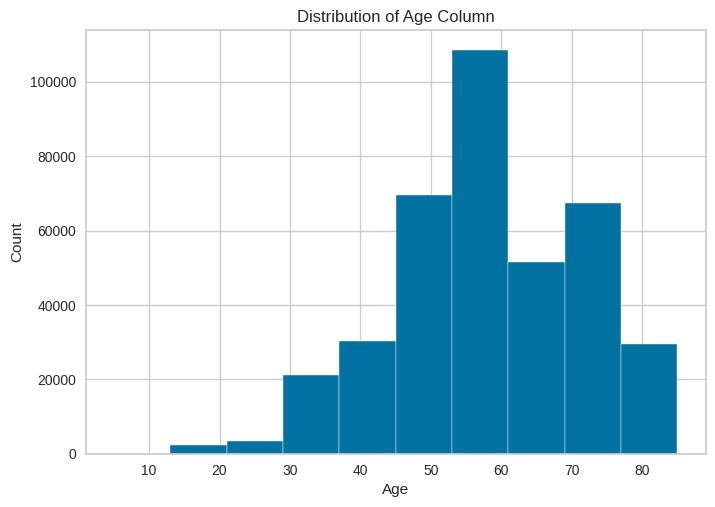

In [161]:
#distribution of approximate age in the hist
df['age'].hist()
plt.title('Distribution of Age Column')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

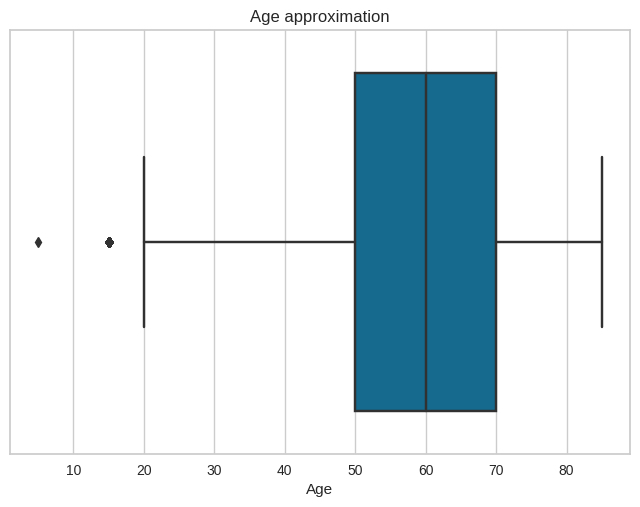

In [162]:
#to show visualization and possible outliers in the age column 
#to show most lesion cases occur in older people or are there any outliers such as younger people with suspected skin cancer

#cancer cases mainly affected in older people between the age of 50 and 70
#few outliers around 10 and 20 years old which means there are rare skin cancer cases in younger people.
sns.boxplot(x=df['age'])
plt.title ("Age approximation")
plt.xlabel ('Age')
plt.show()

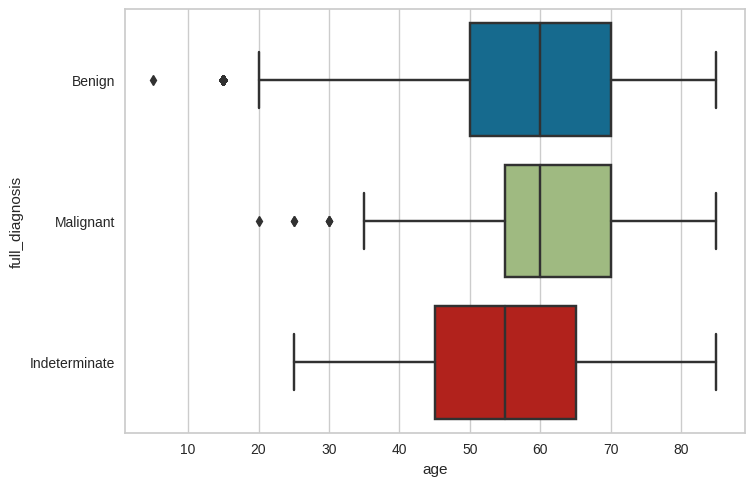

In [163]:
#to show what age people can have what type of skin caner whether if it is benign, malignant or indeterminate
#to show distribution of skin cancer types across different age groups

sns.boxplot(data=df, x='age', y="full_diagnosis")
plt.show()

<Axes: xlabel='count', ylabel='anatom_site_general'>

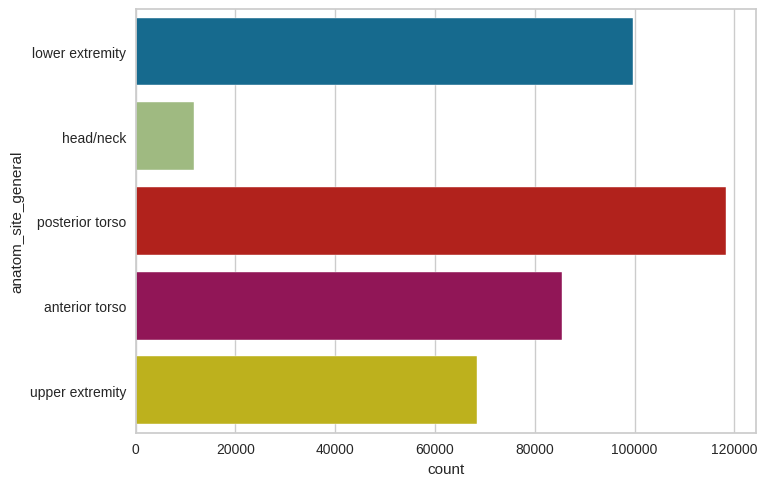

In [164]:
sns.countplot(y='anatom_site_general', data=df)
#use data visualization using with bar chart

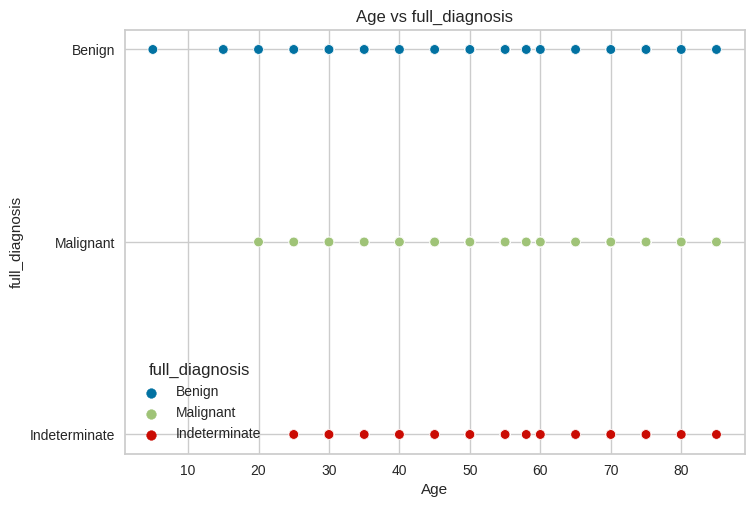

In [165]:
#scatter plot for age vs iddx_1
#to show individual case which can help to identify clusters that might not happen in box plot above
#correlations = whether certain diagnoses are more common in specific age group

#benign cases appear the age ranges from around 20 to 80 years old,with many cases are in middle between the age of 50 to 60 years old
#there will be slightly few  benign cases in younger people betwwen 1 to 10 years old.
#maglinant shows similar distribution to benign cases but not the age of between 1 to 10 years old.

sns.scatterplot(data = df,x = "age", y="full_diagnosis", hue = "full_diagnosis")
plt.title('Age vs full_diagnosis')
plt.xlabel('Age')
plt.ylabel('full_diagnosis')
plt.show()

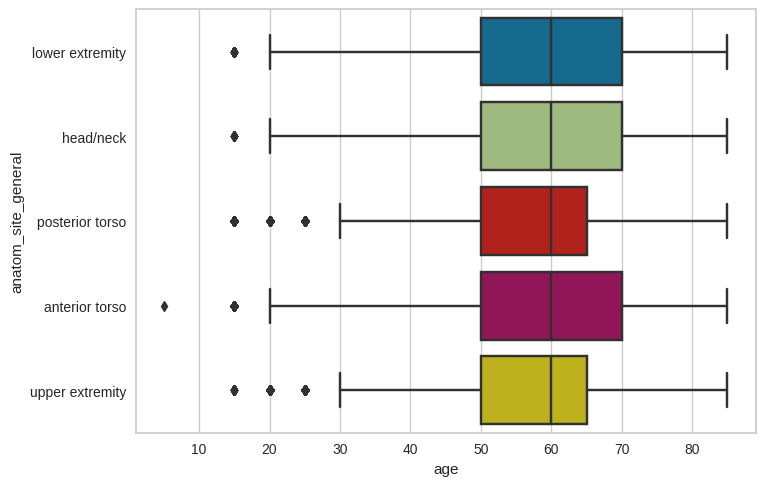

In [166]:
sns.boxplot(data=df, x='age', y="anatom_site_general")
plt.show()
#The very least number of people (outliers)between the age of 15 and 25  have cancers on upper extremity 
# Some people (25%) between the age of 30 and 50 have cancers on upper extremity and the same with people between the age of 65 to 85
#Majority (50%) between the age of 50 and 65 have upper extremity

#boxplot

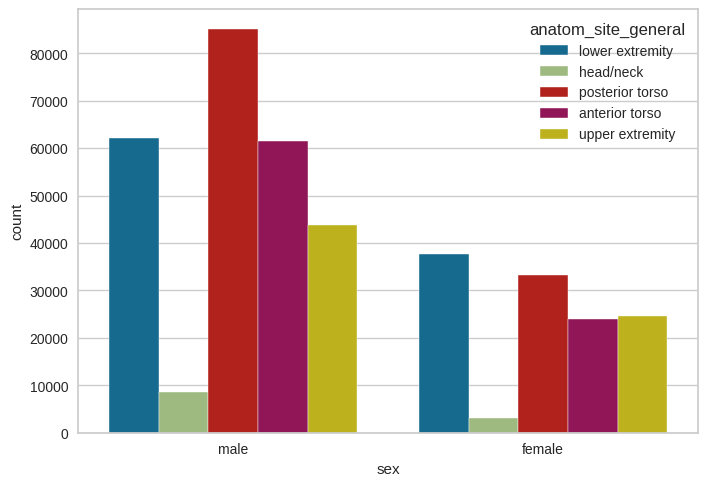

In [167]:
sns.countplot(x='sex', data=df, hue='anatom_site_general'  ) 
plt.show()
# seaborn to create count plot and plt for plot display
#barplot to show distribution of skin cancer occurance betwwen men and women based on body location
#to identify certain body areas are more prone to skin cancer based on gender
# The vast majority of males around over 80000 have cancer on posterior torso compared to the minority of 35000 females.

<Axes: xlabel='anatom_site_general'>

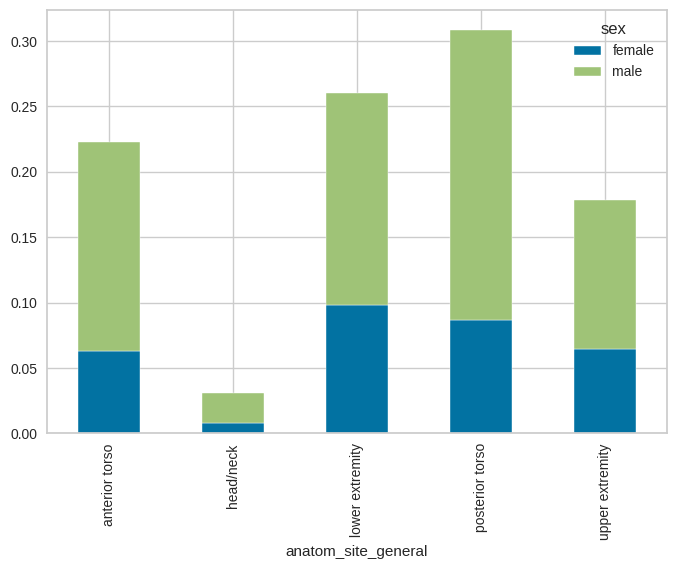

In [168]:
crosstab = pd.crosstab(df['anatom_site_general'], df['sex'], normalize=True)
crosstab.plot(kind='bar', stacked=True, grid=True)

#calculate proportion of occurance in stacked bar chart 
#stacked bar chart
#crosstab shows proportion of skin cancer cases by anatomical site and gender
#posterior torso (back region of the body) has the highest overall poprtion of 30 percent with males having a significantly larger share than females


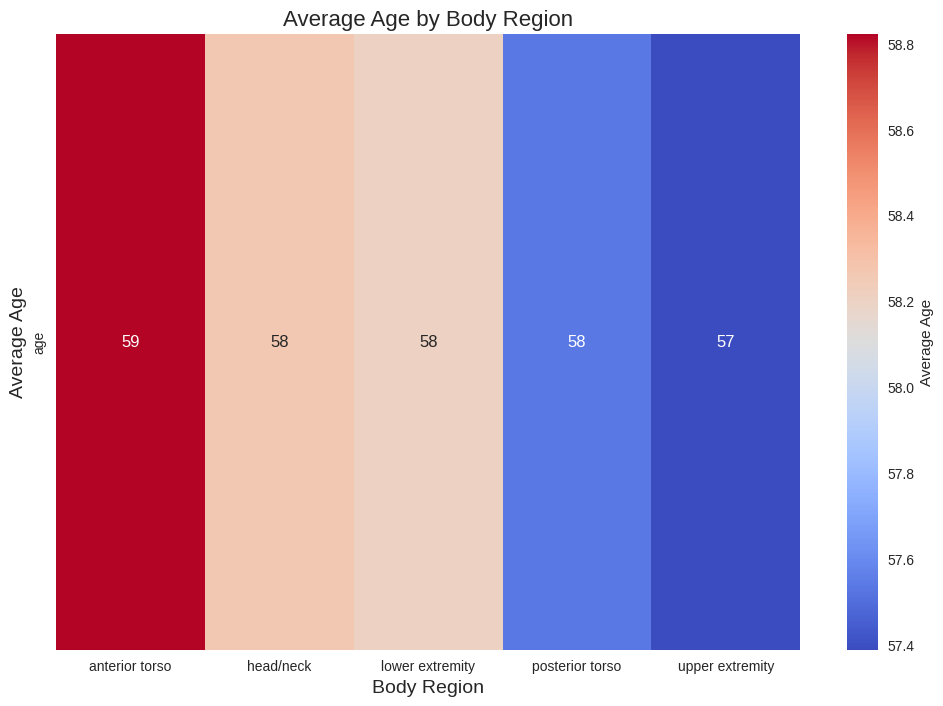

In [169]:
# Group by body region and calculate the mean age per region
age_by_location = df.groupby('anatom_site_general')['age'].mean().reset_index()

# Create a heatmap-like bar plot for visualisation
plt.figure(figsize=(12, 8))
sns.heatmap(age_by_location.set_index('anatom_site_general').T, annot=True, cmap='coolwarm', cbar_kws={'label': 'Average Age'})

plt.title('Average Age by Body Region', fontsize=16)
plt.xlabel('Body Region', fontsize=14)
plt.ylabel('Average Age', fontsize=14)

plt.show()

#to show average age of skin cancer occurrence to different body regions
#to show any age-related pattern where skin cancer develops
#anterior torso (front)shows the highest average age at 59 years old compared to upper extremity shows the lowest average age at 57 years old
#correlation between body region and age of skin cancer occurrence.

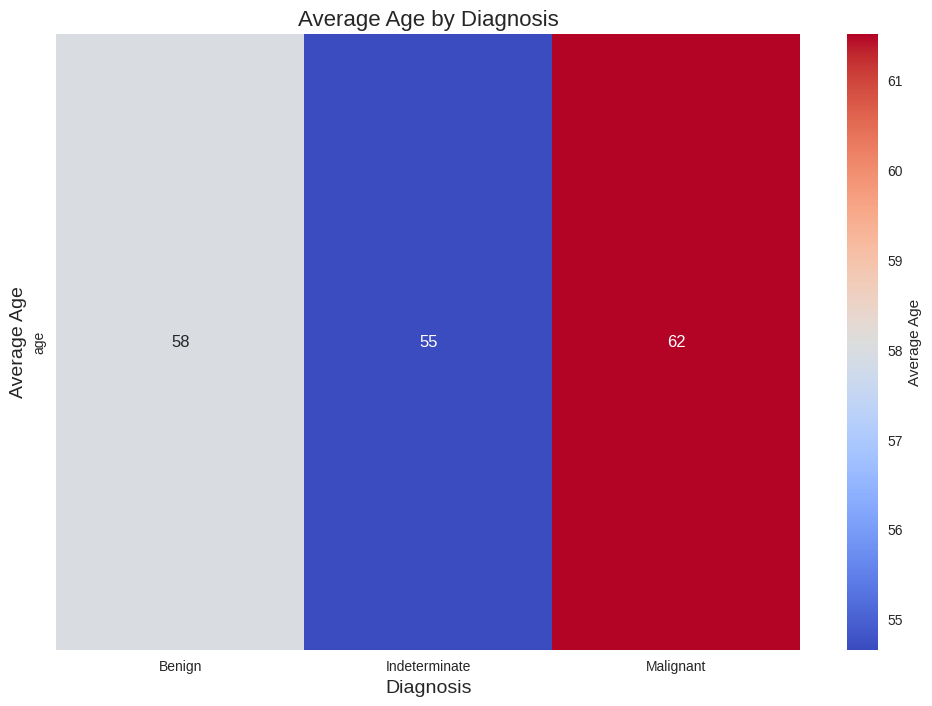

In [170]:
# Group by diagnosis and calculate the mean age per region
age_by_diagnosis = df.groupby('full_diagnosis')['age'].mean().reset_index()

# Create a heatmap-like bar plot for visualisation
plt.figure(figsize=(12, 8))
sns.heatmap(age_by_diagnosis.set_index('full_diagnosis').T, annot=True, cmap='coolwarm', cbar_kws={'label': 'Average Age'})

plt.title('Average Age by Diagnosis', fontsize=16)
plt.xlabel('Diagnosis', fontsize=14)
plt.ylabel('Average Age', fontsize=14)

plt.show()

#to show average age of patients for each type of skin cancer diagnosis
#correlation between age and diagnosis type with malignant cases show the highest average age at 62 years old 
#benign case fall in the middle at 58 years old 

In [171]:
df.shape

(383794, 11)

In [172]:
#the majority of lesions fall into low confidence with over 250 benign cases.
#the count of benign cases decrease significantly into medicum high confidence levels 


#the number of malignant lesions is lower compared to benign lessions.
#most malignant lesions fall into low confidence compared to fewer malignant lesions in medium and high confidence

#the indeterminate has the least count overall . they are only present in low confidence 

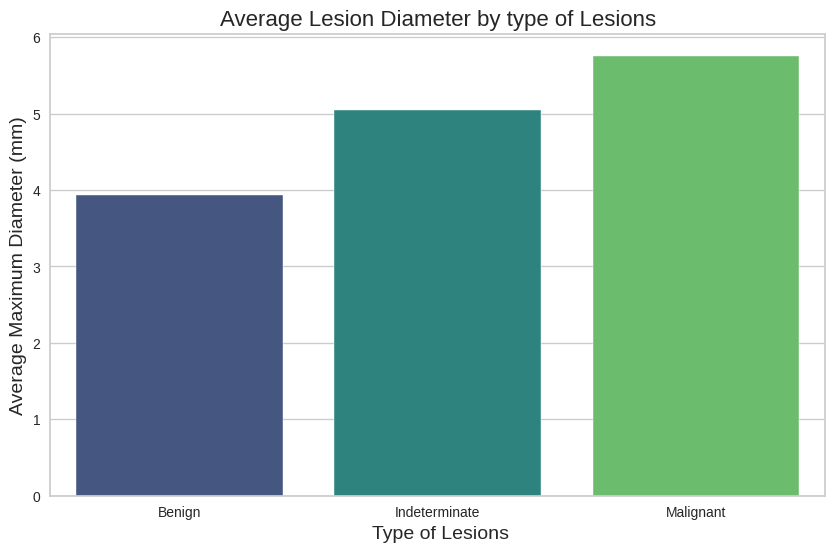

In [173]:
# Calculate the mean maximum diameter by type of lesions
meanDiameter = df.groupby('full_diagnosis')['lesion_diameter_mm'].mean().reset_index()

# Create a bar plot for the average diameter
plt.figure(figsize=(10, 6))
sns.barplot(data=meanDiameter, x='full_diagnosis', y='lesion_diameter_mm', palette='viridis')

# Title and labels
plt.title('Average Lesion Diameter by type of Lesions', fontsize=16)
plt.xlabel(' Type of Lesions', fontsize=14)
plt.ylabel('Average Maximum Diameter (mm)', fontsize=14)

plt.show()


#to show average maximum diameter to lesions for eachtype of diagonis
#to analyze lesion size correlates with diagnois type
#malignant lesions have largest average diameter which aligns with medical findings as cancerous lesions often grow larger than benign ones
#indeterminate lesions have medium average diameter which suggests some of them could be potentially malignant but not certain.

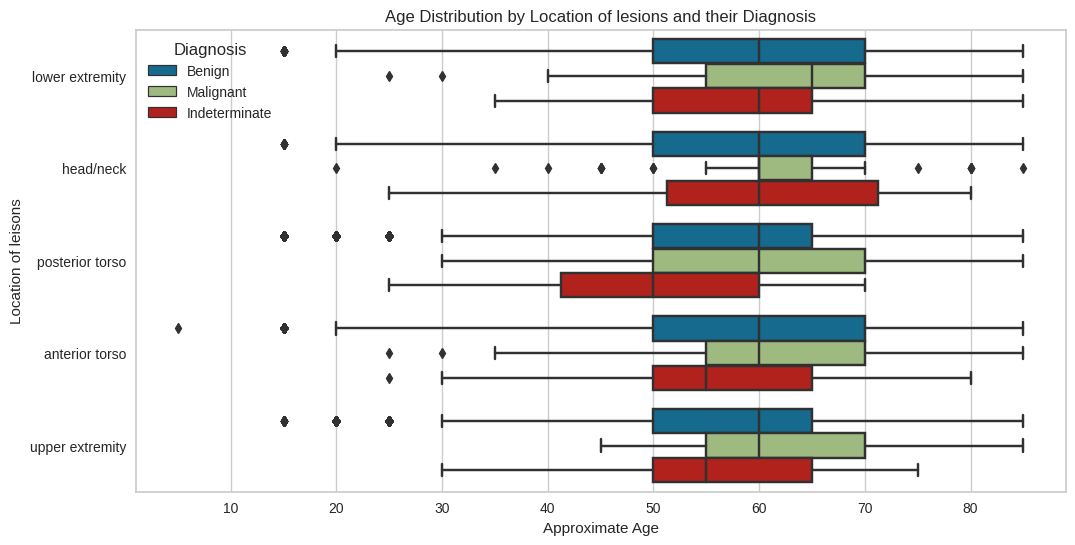

In [174]:
plt.figure(figsize=(12, 6))

sns.boxplot(x='age', y="anatom_site_general", data=df, hue='full_diagnosis')

# Customise the plot
plt.title("Age Distribution by Location of lesions and their Diagnosis")
plt.xlabel("Approximate Age")
plt.ylabel("Location of leisons")
plt.legend(title="Diagnosis")

plt.show()

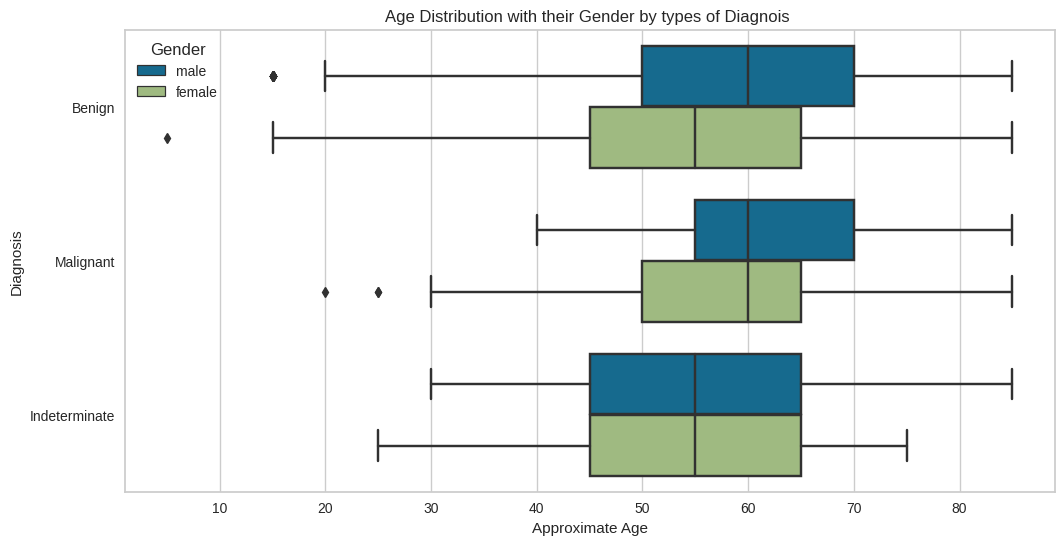

In [175]:
plt.figure(figsize=(12, 6))

sns.boxplot(x='age', y="full_diagnosis", data=df, hue= "sex")

# Customise the plot
plt.title("Age Distribution with their Gender by types of Diagnois ")
plt.xlabel("Approximate Age")
plt.ylabel("Diagnosis")
plt.legend(title="Gender")

plt.show()

In [176]:
df.head()

,isic_id,target,patient_id,age,sex,anatom_site_general,image_type,lesion_diameter_mm,first_diagnosis,lesion_confidence_score,full_diagnosis
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,TBP tile: close-up,3.04,Benign,97.517282,Benign
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,TBP tile: close-up,1.10,Benign,3.141455,Benign
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,TBP tile: close-up,3.40,Benign,99.804040,Benign
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,TBP tile: close-up,3.22,Benign,99.989998,Benign
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,TBP tile: close-up,2.73,Benign,70.442510,Benign


In [177]:
df.head()

,isic_id,target,patient_id,age,sex,anatom_site_general,image_type,lesion_diameter_mm,first_diagnosis,lesion_confidence_score,full_diagnosis
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,TBP tile: close-up,3.04,Benign,97.517282,Benign
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,TBP tile: close-up,1.10,Benign,3.141455,Benign
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,TBP tile: close-up,3.40,Benign,99.804040,Benign
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,TBP tile: close-up,3.22,Benign,99.989998,Benign
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,TBP tile: close-up,2.73,Benign,70.442510,Benign


In [178]:
df.shape

(383794, 11)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


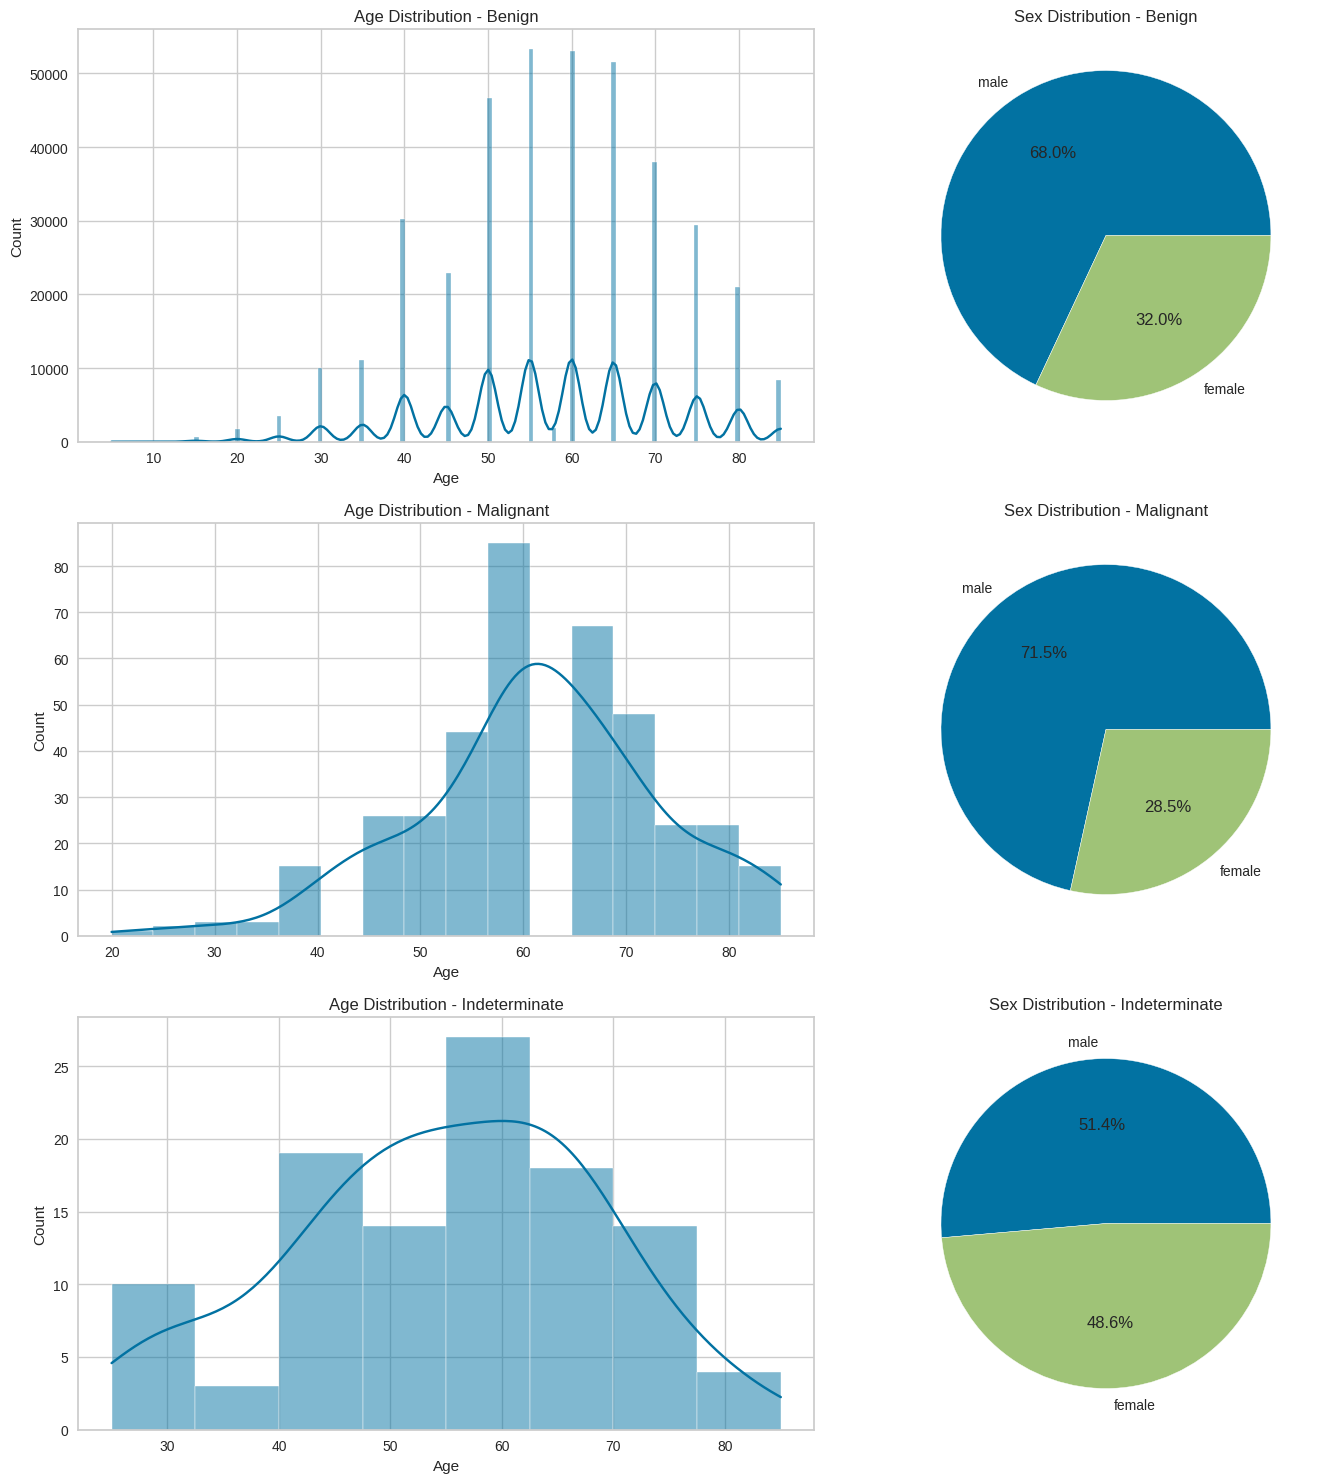

In [179]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# List of diagnoses
diagnoses = ['Benign', 'Malignant', 'Indeterminate']

# Create a figure with 3 rows (one for each diagnosis) and 2 columns (age and sex)
fig, axes = plt.subplots(len(diagnoses), 2, figsize=(15, 15))

# For each diagnosis type
for i, diagnosis in enumerate(diagnoses):
    # Filter data for this diagnosis
    filtered_df = df[df['full_diagnosis'] == diagnosis]
    
    if len(filtered_df) > 0:
        # Age distribution (left column)
        sns.histplot(filtered_df['age'], kde=True, ax=axes[i, 0])
        axes[i, 0].set_title(f'Age Distribution - {diagnosis}')
        axes[i, 0].set_xlabel('Age')
        
        # Sex distribution (right column)
        sex_counts = filtered_df['sex'].value_counts()
        axes[i, 1].pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%')
        axes[i, 1].set_title(f'Sex Distribution - {diagnosis}')
    else:
        axes[i, 0].text(0.5, 0.5, f'No data for {diagnosis}', 
                      horizontalalignment='center', verticalalignment='center')
        axes[i, 1].text(0.5, 0.5, f'No data for {diagnosis}', 
                      horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.savefig('diagnosis_demographics.png')
plt.show()

<Figure size 1200x700 with 0 Axes>

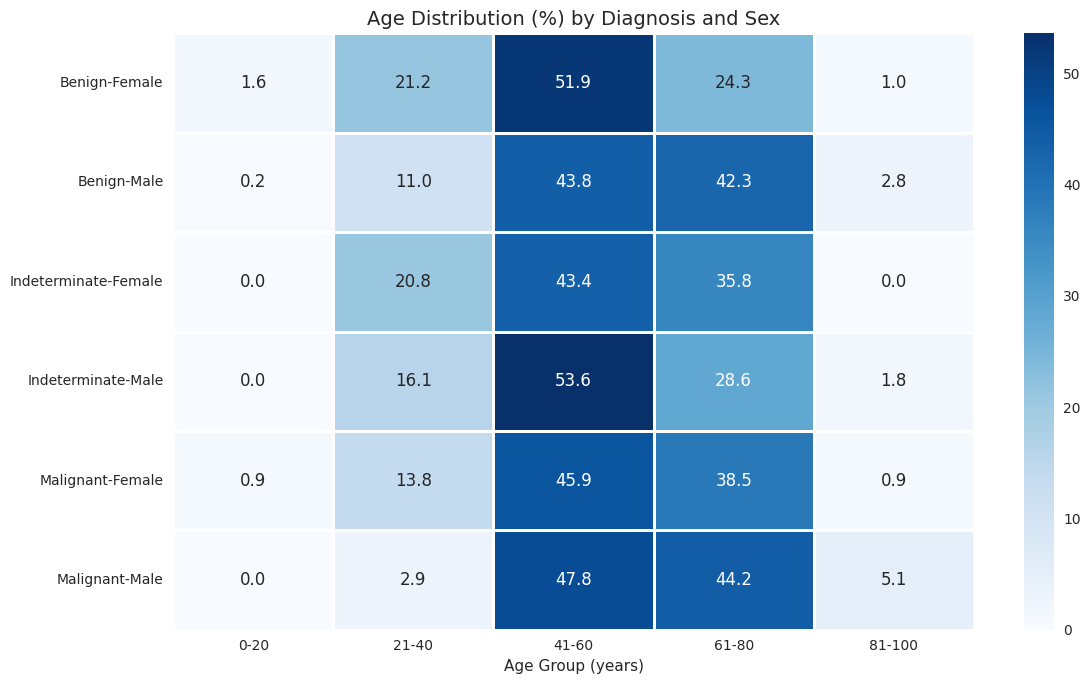

In [180]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.set_style("white")

# Create age bins and results list
age_bins = [0, 20, 40, 60, 80, 100]
age_labels = ['0-20', '21-40', '41-60', '61-80', '81-100']
result = []

# Process each diagnosis-sex combination
for diagnosis in ['Benign', 'Malignant', 'Indeterminate']:
    for sex in ['male', 'female']:
        filtered = df[(df['full_diagnosis'] == diagnosis) & (df['sex'] == sex)].copy()
        if len(filtered) == 0:
            continue
            
        # Add age groups and calculate percentages
        filtered.loc[:, 'age_group'] = pd.cut(filtered['age'], bins=age_bins, labels=age_labels)
        counts = filtered['age_group'].value_counts(normalize=True).reset_index()
        counts.columns = ['age_group', 'percentage']
        counts['category'] = f"{diagnosis}-{sex.capitalize()}"
        result.append(counts)

# Create and display heatmap
if result:
    combined = pd.concat(result)
    pivot_data = combined.pivot(index='category', columns='age_group', values='percentage') * 100
    
    plt.figure(figsize=(12, 7))
    sns.heatmap(pivot_data.fillna(0), annot=True, fmt='.1f', cmap='Blues', linewidths=1)
    plt.title('Age Distribution (%) by Diagnosis and Sex', fontsize=14)
    plt.xlabel('Age Group (years)')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

In [181]:
df['target'].value_counts()

target
0    383411
1       383
Name: count, dtype: int64

In [182]:
df['lesion_confidence_score'].value_counts()

lesion_confidence_score
100.000000    68501
99.999990      7681
99.999988      7002
99.999980      4064
99.999976      3575
              ...  
95.580924         1
99.931650         1
99.671030         1
97.158250         1
98.780584         1
Name: count, Length: 127392, dtype: int64

In [183]:
df['lesion_diameter_mm'].value_counts()

lesion_diameter_mm
2.60     13504
2.70      7247
2.74      7173
3.00      6752
2.88      6410
         ...  
15.55        1
20.88        1
23.30        1
17.06        1
16.77        1
Name: count, Length: 1752, dtype: int64

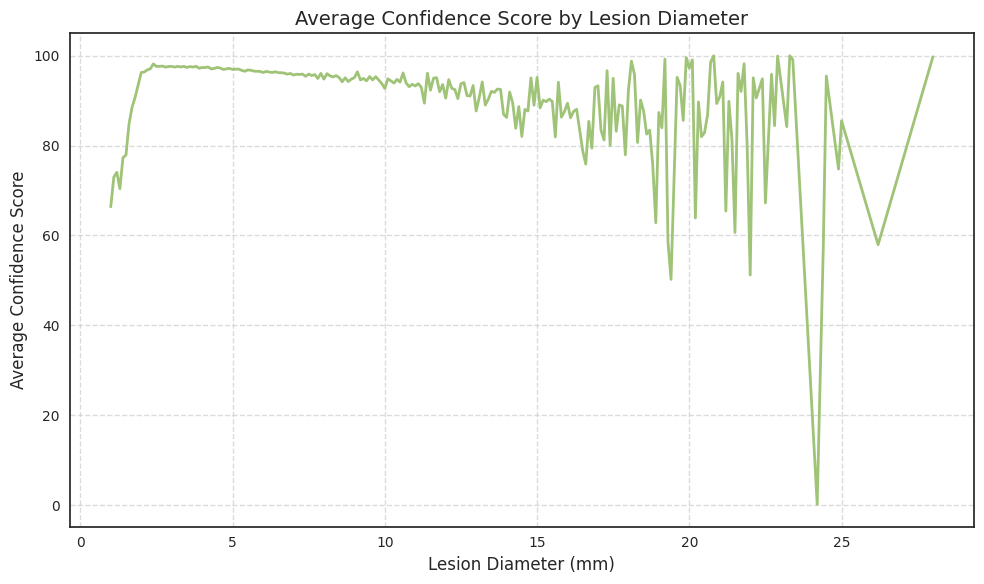

In [184]:
import matplotlib.pyplot as plt
import pandas as pd

# Group by diameter (rounded to nearest 0.1mm) and calculate mean confidence score
df['diameter_rounded'] = df['lesion_diameter_mm'].round(1)
diameter_confidence = df.groupby('diameter_rounded')['lesion_confidence_score'].mean()

# Create figure
plt.figure(figsize=(10, 6))

# Plot the line
plt.plot(diameter_confidence.index, diameter_confidence.values, 'g-', linewidth=2)

# Add labels and title
plt.xlabel('Lesion Diameter (mm)', fontsize=12)
plt.ylabel('Average Confidence Score', fontsize=12)
plt.title('Average Confidence Score by Lesion Diameter', fontsize=14)

# Add grid
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

# Feature Engineering & Modelling

In [185]:
df.head()

,isic_id,target,patient_id,age,sex,anatom_site_general,image_type,lesion_diameter_mm,first_diagnosis,lesion_confidence_score,full_diagnosis,diameter_rounded
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,TBP tile: close-up,3.04,Benign,97.517282,Benign,3.0
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,TBP tile: close-up,1.10,Benign,3.141455,Benign,1.1
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,TBP tile: close-up,3.40,Benign,99.804040,Benign,3.4
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,TBP tile: close-up,3.22,Benign,99.989998,Benign,3.2
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,TBP tile: close-up,2.73,Benign,70.442510,Benign,2.7


# Cluster Analysis

Preparing data for clustering 

In [186]:
# creating a cluster from the dataframe
cluster_data  = df[['isic_id','target','patient_id','first_diagnosis','age','sex','anatom_site_general','lesion_diameter_mm','lesion_confidence_score']]
cluster_data.head()

,isic_id,target,patient_id,first_diagnosis,age,sex,anatom_site_general,lesion_diameter_mm,lesion_confidence_score
0,ISIC_0015670,0,IP_1235828,Benign,60.0,male,lower extremity,3.04,97.517282
1,ISIC_0015845,0,IP_8170065,Benign,60.0,male,head/neck,1.10,3.141455
2,ISIC_0015864,0,IP_6724798,Benign,60.0,male,posterior torso,3.40,99.804040
3,ISIC_0015902,0,IP_4111386,Benign,65.0,male,anterior torso,3.22,99.989998
4,ISIC_0024200,0,IP_8313778,Benign,55.0,male,anterior torso,2.73,70.442510


In [187]:
X = pd.DataFrame(cluster_data, columns=[ 'lesion_diameter_mm',            
    'age',
    'sex',
    'anatom_site_general'] ) 
X.head()

,lesion_diameter_mm,age,sex,anatom_site_general
0,3.04,60.0,male,lower extremity
1,1.10,60.0,male,head/neck
2,3.40,60.0,male,posterior torso
3,3.22,65.0,male,anterior torso
4,2.73,55.0,male,anterior torso


In [188]:
import pandas as pd
X.head()
X_cluster = pd.get_dummies(X, dtype=int)
X_cluster.head()

,lesion_diameter_mm,age,sex_female,sex_male,anatom_site_general_anterior torso,anatom_site_general_head/neck,anatom_site_general_lower extremity,anatom_site_general_posterior torso,anatom_site_general_upper extremity
0,3.04,60.0,0,1,0,0,1,0,0
1,1.10,60.0,0,1,0,1,0,0,0
2,3.40,60.0,0,1,0,0,0,1,0
3,3.22,65.0,0,1,1,0,0,0,0
4,2.73,55.0,0,1,1,0,0,0,0


In [189]:
#create the target class label y = X_cluster['target']
Y_cluster =cluster_data['target']
Y_cluster.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [190]:
cluster_data['target'].value_counts()

target
0    383411
1       383
Name: count, dtype: int64

In [191]:
X_cluster = pd.get_dummies(X, dtype=int)
Y_cluster = cluster_data['target']

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:8

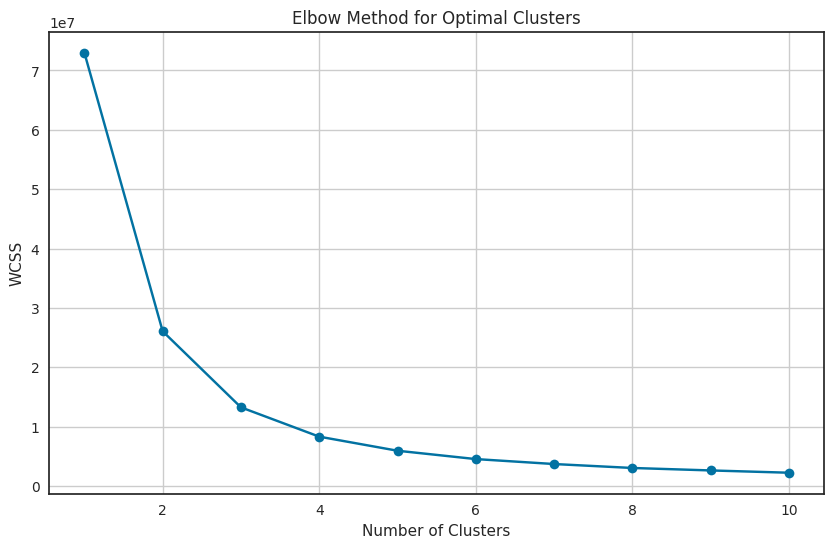

In [192]:
from sklearn.cluster import KMeans
# Find optimal number of clusters using Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i,  init='k-means++',random_state=42)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')  # Within-cluster sum of squares
plt.grid(True)
plt.show()


In [193]:
kMeans = KMeans(n_clusters=4)
Y_cluster = kMeans.fit_predict(X_cluster)
print(Y_cluster[0:5])
cluster_data['CLabel'] = Y_cluster 
cluster_data.head()

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


[0 0 0 0 3]


/tmp/ipykernel_31/897223958.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data['CLabel'] = Y_cluster


,isic_id,target,patient_id,first_diagnosis,age,sex,anatom_site_general,lesion_diameter_mm,lesion_confidence_score,CLabel
0,ISIC_0015670,0,IP_1235828,Benign,60.0,male,lower extremity,3.04,97.517282,0
1,ISIC_0015845,0,IP_8170065,Benign,60.0,male,head/neck,1.10,3.141455,0
2,ISIC_0015864,0,IP_6724798,Benign,60.0,male,posterior torso,3.40,99.804040,0
3,ISIC_0015902,0,IP_4111386,Benign,65.0,male,anterior torso,3.22,99.989998,0
4,ISIC_0024200,0,IP_8313778,Benign,55.0,male,anterior torso,2.73,70.442510,3


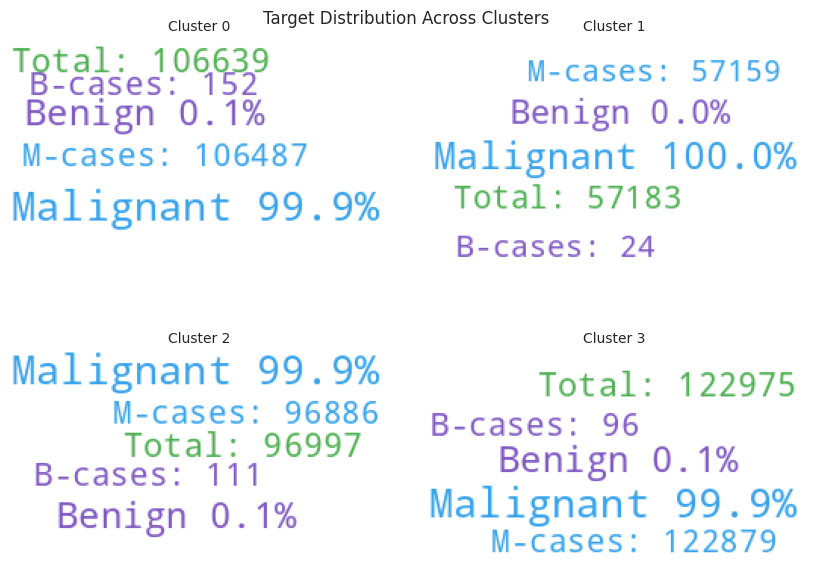

In [194]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Number of clusters
n_clusters = 4
plt.figure(figsize=(8, 6)) 


colors = {
    'malignant': '#36a2eb',   # Blue
    'benign': '#7e57c2',      # Purple
    'total': '#4caf50'        # Green
}

# For each cluster
for i in range(n_clusters):
    # Get data for this cluster
    cluster_subset = cluster_data[cluster_data['CLabel'] == i]
    
    if len(cluster_subset) == 0:
        continue
    
    # Create subplot
    plt.subplot(2, 2, i+1)
    
    # Create word dictionary
    word_dict = {}
    
    # Get counts
    total_cases = len(cluster_subset)
    benign_cases = sum(cluster_subset['target'] == 1)
    malignant_cases = sum(cluster_subset['target'] == 0)
    
    # Calculate percentages
    benign_percent = (benign_cases / total_cases) * 100
    malignant_percent = (malignant_cases / total_cases) * 100
    
    word_dict[f"Malignant {malignant_percent:.1f}%"] = int(150 + malignant_percent * 2)
    word_dict[f"Benign {benign_percent:.1f}%"] = int(150 + benign_percent * 2)
    word_dict[f"Total: {total_cases}"] = 100
    word_dict[f"M-cases: {malignant_cases}"] = 80
    word_dict[f"B-cases: {benign_cases}"] = 80
    
    # Define a custom color function to ensure consistent colors
    def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
        if 'Malignant' in word or 'M-cases' in word:
            return colors['malignant']
        elif 'Benign' in word or 'B-cases' in word:
            return colors['benign']
        else:
            return colors['total']
    
    wordcloud = WordCloud(
        width=250,           
        height=150,       
        background_color='white',
        max_words=5,         
        prefer_horizontal=1.0,
        color_func=color_func,
        relative_scaling=0.2, 
        min_font_size=8,       
        max_font_size=30      
    ).generate_from_frequencies(word_dict)
    
    # Display the word cloud
    plt.imshow(wordcloud)
    plt.title(f'Cluster {i}', fontsize=10)  
    plt.axis('off')

# Remove the legend to save space
plt.suptitle('Target Distribution Across Clusters', fontsize=12, y=0.98)
plt.tight_layout(pad=0.2)  
plt.subplots_adjust(wspace=0.1, hspace=0.2)  
plt.show()

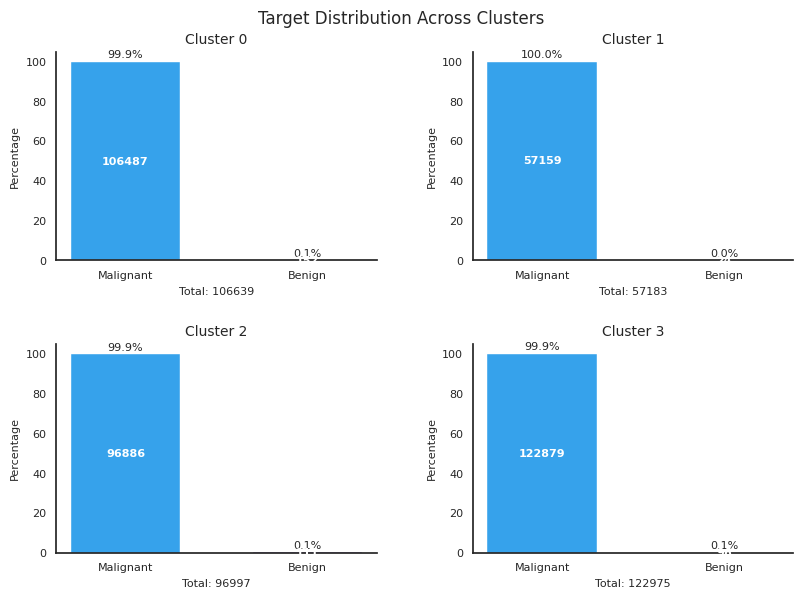

In [195]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Number of clusters
n_clusters = 4

# Create figure with compact size
plt.figure(figsize=(8, 6))

# Define colors
malignant_color = '#36a2eb'  # Blue
benign_color = '#7e57c2'     # Purple

# For each cluster
for i in range(n_clusters):
    # Get data for this cluster
    cluster_subset = cluster_data[cluster_data['CLabel'] == i]
    
    if len(cluster_subset) == 0:
        continue
    
    # Create subplot
    ax = plt.subplot(2, 2, i+1)
    
    # Get counts
    total_cases = len(cluster_subset)
    benign_cases = sum(cluster_subset['target'] == 1)
    malignant_cases = sum(cluster_subset['target'] == 0)
    
    # Calculate percentages
    benign_percent = (benign_cases / total_cases) * 100
    malignant_percent = (malignant_cases / total_cases) * 100
    
    # Create bar chart data
    categories = ['Malignant', 'Benign']
    values = [malignant_percent, benign_percent]
    counts = [malignant_cases, benign_cases]
    colors = [malignant_color, benign_color]
    
    # Plot bars
    bars = ax.bar(categories, values, color=colors, width=0.6)
    
    # Add percentage labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=8)
    
    # Add count labels inside bars
    for j, (bar, count) in enumerate(zip(bars, counts)):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
                f'{count}', ha='center', va='center', 
                color='white', fontweight='bold', fontsize=8)
    
    # Add total cases as text
    ax.text(0.5, -0.15, f'Total: {total_cases}', ha='center', va='center',
            transform=ax.transAxes, fontsize=8)
    
    # Customize appearance
    ax.set_ylim(0, 105)  
    ax.set_title(f'Cluster {i}', fontsize=10)
    ax.set_ylabel('Percentage', fontsize=8)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Add overall title
plt.suptitle('Target Distribution Across Clusters', fontsize=12, y=0.98)

# Adjust layout
plt.tight_layout(pad=0.5)
plt.subplots_adjust(wspace=0.3, hspace=0.4)

plt.show()

/tmp/ipykernel_31/3120835674.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data['AgeCategory'] = pd.cut(


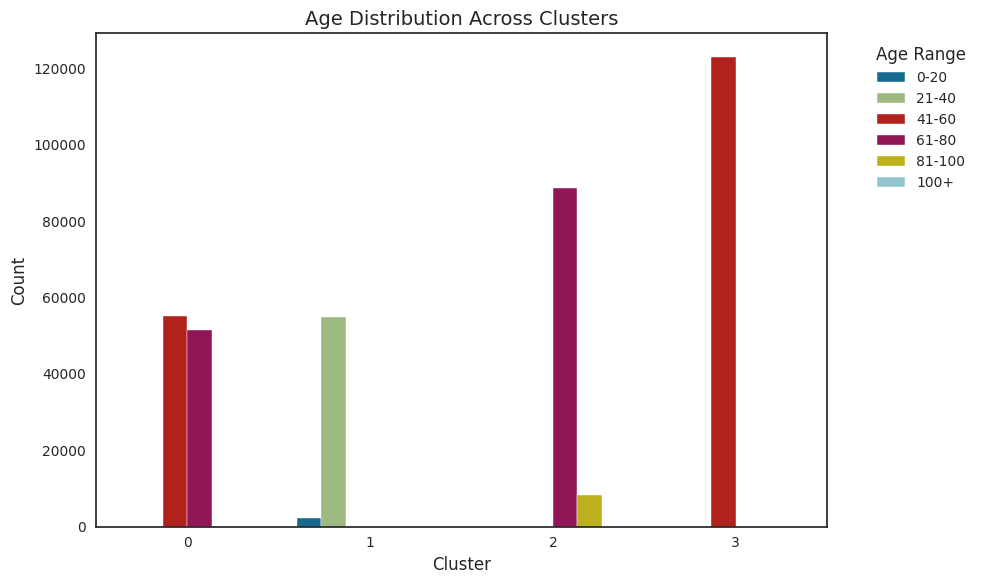

In [196]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Create age categories
cluster_data['AgeCategory'] = pd.cut(
    cluster_data['age'], 
    bins=[0, 20, 40, 60, 80, 100, float('inf')],
    labels=['0-20', '21-40', '41-60', '61-80', '81-100', '100+'],
    right=True  # Includes the right edge of each bin
)

# Set figure size
plt.figure(figsize=(10, 6))

# Create the countplot
sns.countplot(data=cluster_data, x="CLabel", hue="AgeCategory")

# Customize the plot
plt.title('Age Distribution Across Clusters', fontsize=14)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title="Age Range", bbox_to_anchor=(1.05, 1), loc='upper left')

# Improve layout
plt.tight_layout()
plt.show()

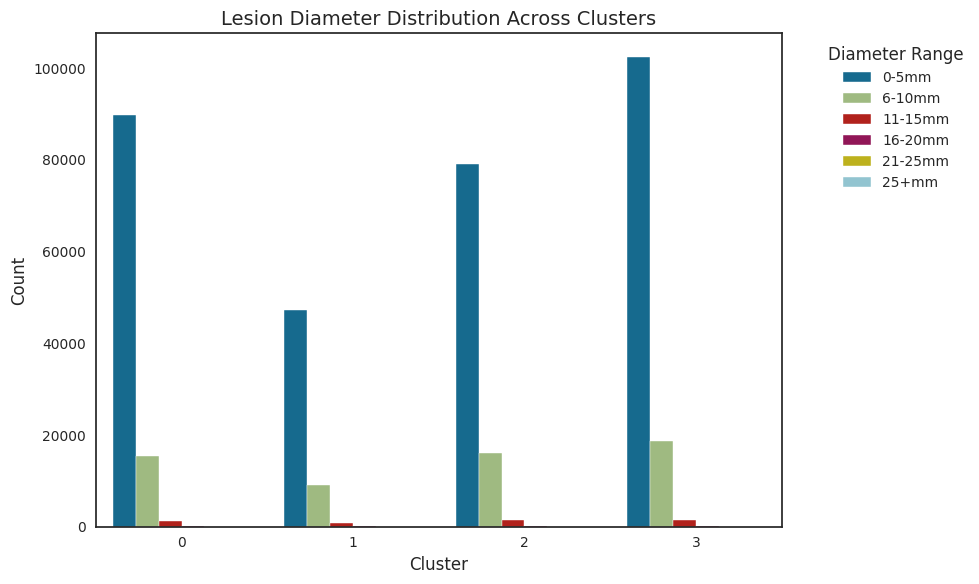

In [197]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Create lesion diameter categories
cluster_data['DiameterCategory'] = pd.cut(
    cluster_data['lesion_diameter_mm'], 
    bins=[0, 5, 10, 15, 20, 25, float('inf')],
    labels=['0-5mm', '6-10mm', '11-15mm', '16-20mm', '21-25mm', '25+mm'],
    right=True  # Includes the right edge of each bin
)

# Set figure size
plt.figure(figsize=(10, 6))

# Create the countplot
sns.countplot(data=cluster_data, x="CLabel", hue="DiameterCategory")

# Customize the plot
plt.title('Lesion Diameter Distribution Across Clusters', fontsize=14)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title="Diameter Range", bbox_to_anchor=(1.05, 1), loc='upper left')

# Improve layout
plt.tight_layout()
plt.show()

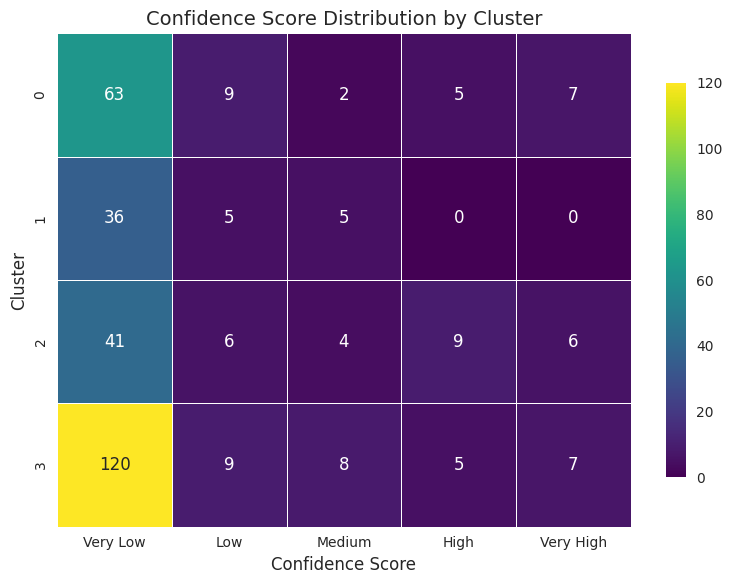

In [198]:
# Create a more compact, cleaner heatmap
plt.figure(figsize=(8, 6))  # Smaller figure size

cluster_data['ConfidenceCategory'] = pd.cut(
    cluster_data['lesion_confidence_score'], 
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

# Create cross-tabulation
confidence_cluster_counts = pd.crosstab(cluster_data['CLabel'], cluster_data['ConfidenceCategory'])

# Plot improved heatmap
ax = sns.heatmap(
    confidence_cluster_counts, 
    annot=True,                 # Show values
    cmap='viridis',             # Different color scheme for better contrast
    fmt='d',                    # Format as integers
    annot_kws={"size": 12},     # Moderate font size
    linewidths=0.5,             # Add grid lines
    cbar_kws={'shrink': 0.8}    # Smaller color bar
)

# Cleaner title and labels
plt.title('Confidence Score Distribution by Cluster', fontsize=14)
plt.ylabel('Cluster', fontsize=12)
plt.xlabel('Confidence Score', fontsize=12)

# Better spacing
plt.tight_layout()
plt.show()

Using a sample of 5000 points instead of 383794


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


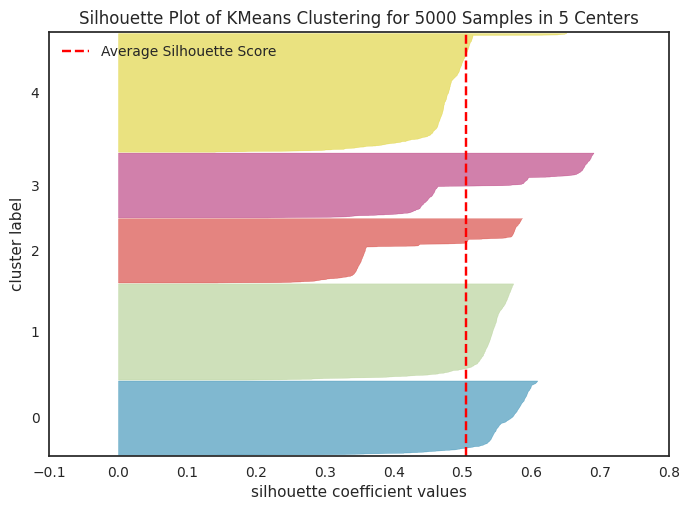

Silhouette Score: 0.505


In [199]:
import numpy as np
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans

# Set random seed for reproducibility
np.random.seed(42)

# Create a new K-means instance
new_kmeans = KMeans(n_clusters=5, random_state=42)

# Create the visualizer with the new model
New_visualizer = SilhouetteVisualizer(new_kmeans, colors='yellowbrick')

# Sample data if needed
if len(X_cluster) > 5000:  
    sample_indices = np.random.choice(len(X_cluster), size=5000, replace=False)
    X_cluster_sample = X_cluster.iloc[sample_indices].values
    print(f"Using a sample of {len(X_cluster_sample)} points instead of {len(X_cluster)}")
    New_visualizer.fit(X_cluster_sample)
else:
    New_visualizer.fit(X_cluster_array)

# Show the visualizer
New_visualizer.show()

# Print the silhouette score
print(f"Silhouette Score: {New_visualizer.silhouette_score_:.3f}")

# Visualization comparing mulitple  images from the skin cancer clusters

Image directory exists: True
Sample files in directory: ['ISIC_9730802.jpg', 'ISIC_2834883.jpg', 'ISIC_5115027.jpg']
Sample of cluster data:
        isic_id  CLabel  target  lesion_diameter_mm
0  ISIC_0015670       0       0                3.04
1  ISIC_0015845       0       0                1.10
2  ISIC_0015864       0       0                3.40
3  ISIC_0015902       0       0                3.22
4  ISIC_0024200       3       0                2.73
Looking for image: /kaggle/input/isic-2024-skin-cancer-detection/train-image/image/ISIC_1967462.jpg
File exists: True
Looking for image: /kaggle/input/isic-2024-skin-cancer-detection/train-image/image/ISIC_5287218.jpg
File exists: True
Looking for image: /kaggle/input/isic-2024-skin-cancer-detection/train-image/image/ISIC_9031244.jpg
File exists: True
Looking for image: /kaggle/input/isic-2024-skin-cancer-detection/train-image/image/ISIC_6818182.jpg
File exists: True
Looking for image: /kaggle/input/isic-2024-skin-cancer-detection/train-imag

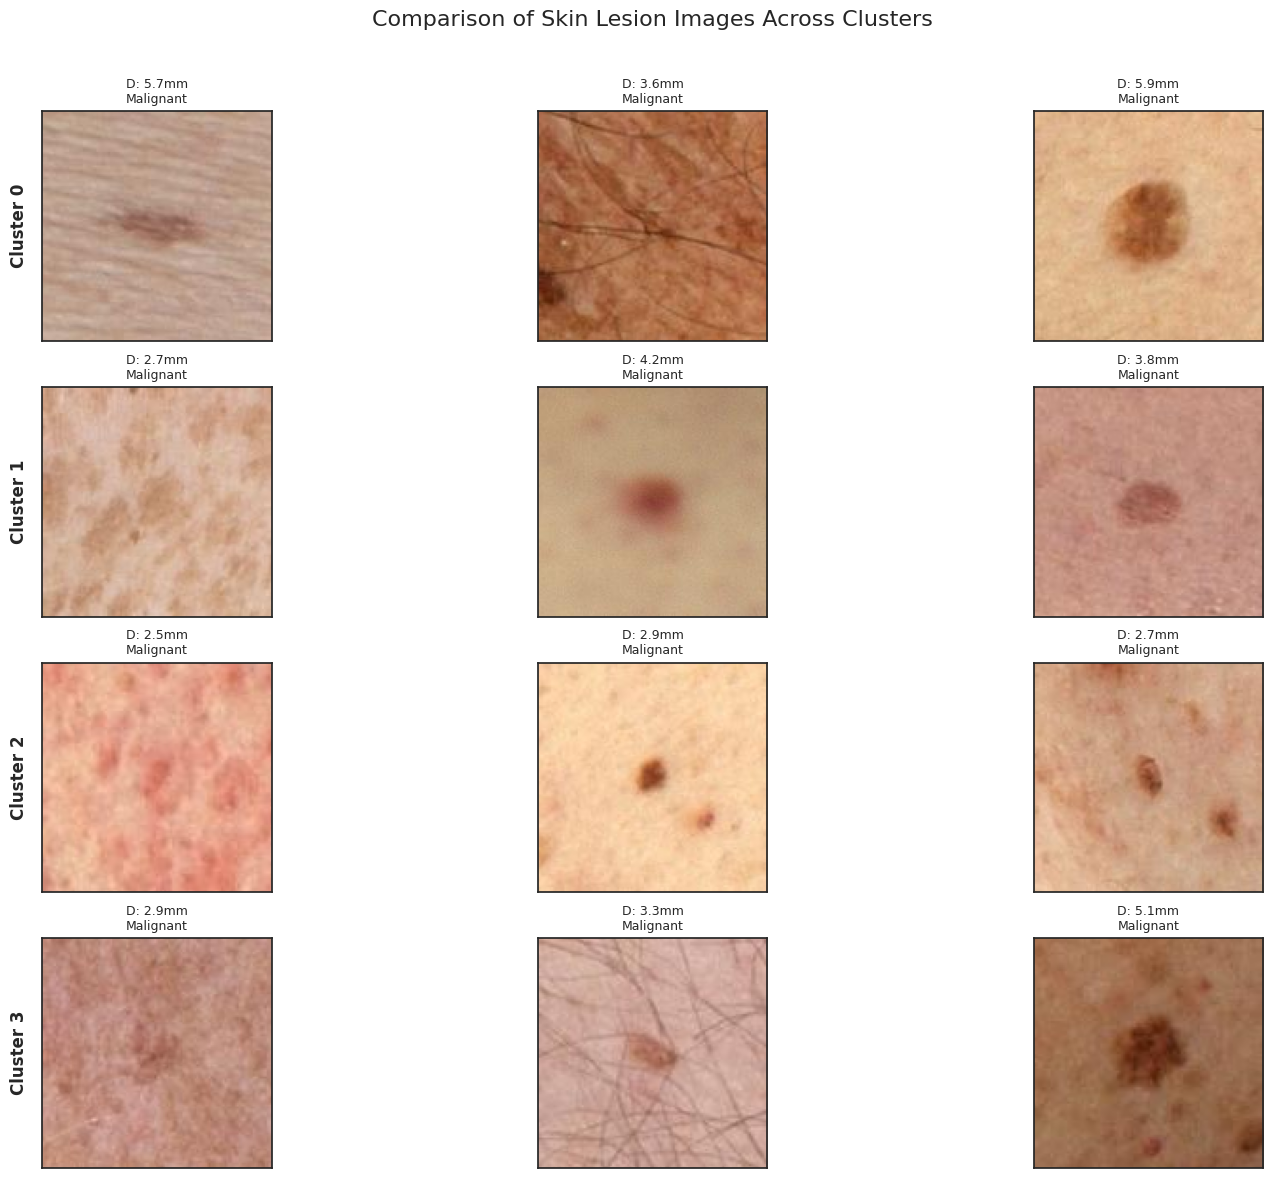

Figure saved as 'cluster_images_comparison.png'


In [200]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.utils import shuffle
import os

# Function to create a visualization of multiple images from each cluster
def visualize_cluster_images(cluster_data, image_dir, n_images=3, figsize=(15, 12)):
    """
    Create a grid of images from each cluster for comparison
    
    Parameters:
    -----------
    cluster_data : DataFrame
        DataFrame containing cluster assignments and image IDs
    image_dir : str
        Directory containing the skin lesion images
    n_images : int
        Number of images to display per cluster
    figsize : tuple
        Figure size (width, height)
    """
    # Get unique clusters
    clusters = sorted(cluster_data['CLabel'].unique())
    n_clusters = len(clusters)
    
    # Create figure
    fig, axes = plt.subplots(n_clusters, n_images, figsize=figsize)
    
    # Loop through each cluster
    for i, cluster in enumerate(clusters):
        # Get data for this cluster
        cluster_subset = cluster_data[cluster_data['CLabel'] == cluster]
        
        # Shuffle and select n_images samples
        samples = shuffle(cluster_subset, random_state=42).iloc[:min(n_images, len(cluster_subset))]
        
        # For each sample, display the image
        for j, (_, sample) in enumerate(samples.iterrows()):
            # Get image path
            image_id = sample['isic_id']
            image_path = os.path.join(image_dir, f"{image_id}.jpg")
            
            # Debug message
            print(f"Looking for image: {image_path}")
            print(f"File exists: {os.path.exists(image_path)}")
            
            # Check if image exists
            if os.path.exists(image_path):
                # Load and display image
                try:
                    img = plt.imread(image_path)
                    axes[i, j].imshow(img)
                    
                    # Add information about the lesion
                    title = f"D: {sample['lesion_diameter_mm']:.1f}mm\n"
                    title += f"{'Malignant' if sample['target'] == 0 else 'Benign'}"
                    axes[i, j].set_title(title, fontsize=9)
                    
                except Exception as e:
                    axes[i, j].text(0.5, 0.5, f"Error: {str(e)}", 
                                    ha='center', va='center')
                    print(f"Error loading image {image_path}: {str(e)}")
            else:
                axes[i, j].text(0.5, 0.5, "Image not found", 
                                ha='center', va='center')
                print(f"Image not found: {image_path}")
            
            # Remove ticks
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])
        
        # Add cluster label on the left
        if n_images > 0:
            axes[i, 0].set_ylabel(f"Cluster {cluster}", fontsize=12, 
                                   fontweight='bold', labelpad=10)
    
    # Add overall title
    plt.suptitle("Comparison of Skin Lesion Images Across Clusters", fontsize=16, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.subplots_adjust(wspace=0.05, hspace=0.2)
    
    return fig

# Path to the images 
image_dir = "/kaggle/input/isic-2024-skin-cancer-detection/train-image/image/"

# Verify the image directory exists
print(f"Image directory exists: {os.path.exists(image_dir)}")
if os.path.exists(image_dir):
    sample_files = os.listdir(image_dir)[:3]
    print(f"Sample files in directory: {sample_files}")


# Get a sample of the cluster data to check format
print("Sample of cluster data:")
print(cluster_data[['isic_id', 'CLabel', 'target', 'lesion_diameter_mm']].head())

# Generate and display the visualization
fig = visualize_cluster_images(cluster_data, image_dir, n_images=3)
plt.show()
fig.savefig('cluster_images_comparison.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'cluster_images_comparison.png'")

# Model Evaluation

# Data Transformation and normalization

In [201]:
cluster_data.head()

,isic_id,target,patient_id,first_diagnosis,age,sex,anatom_site_general,lesion_diameter_mm,lesion_confidence_score,CLabel,AgeCategory,DiameterCategory,ConfidenceCategory
0,ISIC_0015670,0,IP_1235828,Benign,60.0,male,lower extremity,3.04,97.517282,0,41-60,0-5mm,NaN
1,ISIC_0015845,0,IP_8170065,Benign,60.0,male,head/neck,1.10,3.141455,0,41-60,0-5mm,NaN
2,ISIC_0015864,0,IP_6724798,Benign,60.0,male,posterior torso,3.40,99.804040,0,41-60,0-5mm,NaN
3,ISIC_0015902,0,IP_4111386,Benign,65.0,male,anterior torso,3.22,99.989998,0,61-80,0-5mm,NaN
4,ISIC_0024200,0,IP_8313778,Benign,55.0,male,anterior torso,2.73,70.442510,3,41-60,0-5mm,NaN


In [202]:
cluster_data['ConfidenceCategory'].unique()

[NaN, 'Very Low', 'Low', 'High', 'Very High', 'Medium']
Categories (5, object): ['Very Low' < 'Low' < 'Medium' < 'High' < 'Very High']

In [203]:
cluster_data = cluster_data[cluster_data["ConfidenceCategory"].notna()]
cluster_data["ConfidenceCategory"].unique()

['Very Low', 'Low', 'High', 'Very High', 'Medium']
Categories (5, object): ['Very Low' < 'Low' < 'Medium' < 'High' < 'Very High']

In [204]:
y = cluster_data['target']
y.head()

756     0
1592    0
3481    0
3493    0
4031    0
Name: target, dtype: int64

In [205]:
y.unique()

array([0, 1])

In [206]:
X.head()

,lesion_diameter_mm,age,sex,anatom_site_general
0,3.04,60.0,male,lower extremity
1,1.10,60.0,male,head/neck
2,3.40,60.0,male,posterior torso
3,3.22,65.0,male,anterior torso
4,2.73,55.0,male,anterior torso


In [207]:
cluster_data.head()

,isic_id,target,patient_id,first_diagnosis,age,sex,anatom_site_general,lesion_diameter_mm,lesion_confidence_score,CLabel,AgeCategory,DiameterCategory,ConfidenceCategory
756,ISIC_0091661,0,IP_9552666,Benign,20.0,female,posterior torso,3.86,5.450537e-07,1,0-20,0-5mm,Very Low
1592,ISIC_0112602,0,IP_2870467,Benign,45.0,male,lower extremity,3.38,2.889015e-01,3,41-60,0-5mm,Low
3481,ISIC_0157984,0,IP_5352890,Benign,35.0,male,anterior torso,1.78,1.744470e-02,1,21-40,0-5mm,Very Low
3493,ISIC_0158358,0,IP_6908786,Benign,40.0,female,posterior torso,13.70,9.922159e-02,1,21-40,11-15mm,Very Low
4031,ISIC_0171787,0,IP_5989034,Benign,45.0,male,posterior torso,11.79,1.099911e-07,3,41-60,11-15mm,Very Low


In [208]:
# Ensure both dataframes have the same index or reset indices
X = X.reset_index(drop=True)
cluster_data = cluster_data.reset_index(drop=True)

# Add the columns
X = X.assign(
    ConfidenceCategory=cluster_data['ConfidenceCategory'],
    lesion_diameter_mm=cluster_data['lesion_diameter_mm']
)

# Verify the columns were added correctly
X.head()

,lesion_diameter_mm,age,sex,anatom_site_general,ConfidenceCategory
0,3.86,60.0,male,lower extremity,Very Low
1,3.38,60.0,male,head/neck,Low
2,1.78,60.0,male,posterior torso,Very Low
3,13.70,65.0,male,anterior torso,Very Low
4,11.79,55.0,male,anterior torso,Very Low


In [209]:
original_df['tbp_lv_color_std_mean'].unique()

array([0.        , 0.5145203 , 0.4864972 , ..., 0.49819677, 1.317875  ,
       0.9788666 ])

tbp_lv_color_std_mean	= Color irregularity, calculated as the variance of colors within the lesion's boundary

In [210]:
original_df['tbp_lv_deltaLBnorm'].unique()

array([ 5.78430238,  4.987244  ,  6.290359  , ...,  7.84260703,
        8.51544   , 12.03393   ])

tbp_lv_deltaLBnorm =Contrast between the lesion and its immediate surrounding skin

In [211]:
# Add the columns
X = X.assign(
    tbp_lv_color_std_mean=original_df['tbp_lv_color_std_mean'],
    tbp_lv_deltaBnorm=original_df['tbp_lv_deltaLBnorm']
)

# Verify the columns were added correctly
X.head()

,lesion_diameter_mm,age,sex,anatom_site_general,ConfidenceCategory,tbp_lv_color_std_mean,tbp_lv_deltaBnorm
0,3.86,60.0,male,lower extremity,Very Low,0.00000,5.784302
1,3.38,60.0,male,head/neck,Low,0.00000,4.987244
2,1.78,60.0,male,posterior torso,Very Low,0.00000,6.290359
3,13.70,65.0,male,anterior torso,Very Low,0.51452,6.400196
4,11.79,55.0,male,anterior torso,Very Low,0.00000,6.531302


In [212]:
# Format columns to show only 2 digits after the decimal point
X['tbp_lv_color_std_mean'] = X['tbp_lv_color_std_mean'].round(2)
X['tbp_lv_deltaBnorm'] = X['tbp_lv_deltaBnorm'].round(2)

# Verify the formatting
X.head()

,lesion_diameter_mm,age,sex,anatom_site_general,ConfidenceCategory,tbp_lv_color_std_mean,tbp_lv_deltaBnorm
0,3.86,60.0,male,lower extremity,Very Low,0.00,5.78
1,3.38,60.0,male,head/neck,Low,0.00,4.99
2,1.78,60.0,male,posterior torso,Very Low,0.00,6.29
3,13.70,65.0,male,anterior torso,Very Low,0.51,6.40
4,11.79,55.0,male,anterior torso,Very Low,0.00,6.53


In [213]:
X['lesion_diameter_mm'].unique()

array([ 3.86,  3.38,  1.78, 13.7 , 11.79,  3.15, 16.78,  1.65,  1.5 ,
        1.4 ,  1.51,  2.4 ,  5.13,  1.23,  2.99,  1.46,  1.36,  1.47,
        1.34,  2.09, 16.57,  1.41,  1.1 ,  1.8 ,  2.47,  2.89, 15.1 ,
        1.26,  2.56,  7.52,  4.76,  8.6 , 10.29,  5.8 ,  1.58,  1.16,
        9.11, 11.3 ,  4.47, 10.92,  4.75,  2.77,  3.29,  1.27,  6.23,
        6.8 ,  3.78,  2.21,  1.37,  2.76,  1.04,  1.24, 16.5 ,  4.83,
        2.65, 12.29,  4.85,  2.8 ,  3.99,  6.97,  1.02,  5.62,  1.6 ,
        2.6 ,  2.07,  2.5 ,  8.57,  3.4 ,  3.  ,  4.68,  2.19,  3.09,
        1.33,  4.82, 11.51,  2.  , 14.03,  2.03, 16.45, 14.5 ,  7.7 ,
       10.74, 11.91,  3.16,  1.48,  4.71,  3.58,  1.18,  2.01,  4.16,
        5.75,  1.3 ,  1.86,  3.02,  2.41,  1.01,  3.6 ,  1.84,  3.7 ,
        1.9 ,  5.83,  1.35, 18.94,  2.16,  3.75,  2.55,  1.88,  1.53,
        3.25,  1.45,  9.6 ,  3.12,  3.46,  4.13,  1.52,  3.72,  2.82,
        2.27,  5.47,  2.2 ,  4.35,  1.55,  6.72,  4.33,  2.88,  3.11,
        2.7 ,  3.87,

In [214]:
X = X[X["lesion_diameter_mm"].notna()]

# Get unique values after dropping NaNs
X["lesion_diameter_mm"].unique()

array([ 3.86,  3.38,  1.78, 13.7 , 11.79,  3.15, 16.78,  1.65,  1.5 ,
        1.4 ,  1.51,  2.4 ,  5.13,  1.23,  2.99,  1.46,  1.36,  1.47,
        1.34,  2.09, 16.57,  1.41,  1.1 ,  1.8 ,  2.47,  2.89, 15.1 ,
        1.26,  2.56,  7.52,  4.76,  8.6 , 10.29,  5.8 ,  1.58,  1.16,
        9.11, 11.3 ,  4.47, 10.92,  4.75,  2.77,  3.29,  1.27,  6.23,
        6.8 ,  3.78,  2.21,  1.37,  2.76,  1.04,  1.24, 16.5 ,  4.83,
        2.65, 12.29,  4.85,  2.8 ,  3.99,  6.97,  1.02,  5.62,  1.6 ,
        2.6 ,  2.07,  2.5 ,  8.57,  3.4 ,  3.  ,  4.68,  2.19,  3.09,
        1.33,  4.82, 11.51,  2.  , 14.03,  2.03, 16.45, 14.5 ,  7.7 ,
       10.74, 11.91,  3.16,  1.48,  4.71,  3.58,  1.18,  2.01,  4.16,
        5.75,  1.3 ,  1.86,  3.02,  2.41,  1.01,  3.6 ,  1.84,  3.7 ,
        1.9 ,  5.83,  1.35, 18.94,  2.16,  3.75,  2.55,  1.88,  1.53,
        3.25,  1.45,  9.6 ,  3.12,  3.46,  4.13,  1.52,  3.72,  2.82,
        2.27,  5.47,  2.2 ,  4.35,  1.55,  6.72,  4.33,  2.88,  3.11,
        2.7 ,  3.87,

In [215]:
 #encode the nonimal into numerical data to build a machine learning model
X = pd.get_dummies(X, dtype=int)
X.head()

,lesion_diameter_mm,age,tbp_lv_color_std_mean,tbp_lv_deltaBnorm,sex_female,sex_male,anatom_site_general_anterior torso,anatom_site_general_head/neck,anatom_site_general_lower extremity,anatom_site_general_posterior torso,anatom_site_general_upper extremity,ConfidenceCategory_Very Low,ConfidenceCategory_Low,ConfidenceCategory_Medium,ConfidenceCategory_High,ConfidenceCategory_Very High
0,3.86,60.0,0.00,5.78,0,1,0,0,1,0,0,1,0,0,0,0
1,3.38,60.0,0.00,4.99,0,1,0,1,0,0,0,0,1,0,0,0
2,1.78,60.0,0.00,6.29,0,1,0,0,0,1,0,1,0,0,0,0
3,13.70,65.0,0.51,6.40,0,1,1,0,0,0,0,1,0,0,0,0
4,11.79,55.0,0.00,6.53,0,1,1,0,0,0,0,1,0,0,0,0


In [216]:
# If y is a Series, check if it has the same index as X
print("X index length:", len(X.index))
print("y index length:", len(y.index))

X index length: 347
y index length: 347


In [217]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(X_train[0:5])

     lesion_diameter_mm   age  tbp_lv_color_std_mean  tbp_lv_deltaBnorm  \
343                2.90  65.0                   0.41               4.65   
150                3.12  50.0                   1.11               6.04   
54                 6.23  50.0                   0.78               5.34   
127                1.84  80.0                   0.67               6.57   
316                4.55  80.0                   0.77               7.55   

     sex_female  sex_male  anatom_site_general_anterior torso  \
343           0         1                                   1   
150           0         1                                   0   
54            0         1                                   1   
127           0         1                                   0   
316           0         1                                   0   

     anatom_site_general_head/neck  anatom_site_general_lower extremity  \
343                              0                                    0   
150     

# Implementing Classifiers  and hyperparameter tunning

In [218]:
# 1. Decision Tree Classifier 
from sklearn.tree import DecisionTreeClassifier

#tuning the parameter into max_depth
dt_model =DecisionTreeClassifier(criterion='entropy', max_depth = 8, random_state=1) 

In [219]:
#training the model 
dt_model = dt_model.fit(X_train, y_train)

In [224]:
# evaluting model
y_pred = dt_model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.2f}")

Test Accuracy: 0.87


In [225]:
y_pred_proba = dt_model.predict_proba(X_test)[:, 1]

#creating the validation set from the training data
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [229]:
from sklearn.metrics import roc_auc_score
# If your probabilities are already for class 1, just use:
auc = roc_auc_score(y_test, y_pred_proba)
print(f'AUC: {auc:.4f}')

AUC: 0.4792


In [230]:
# Invert the probabilities
y_pred_proba_fixed = 1 - y_pred_proba 
# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba_fixed)
print(f"AUC: {auc:.4f}")

AUC: 0.5208


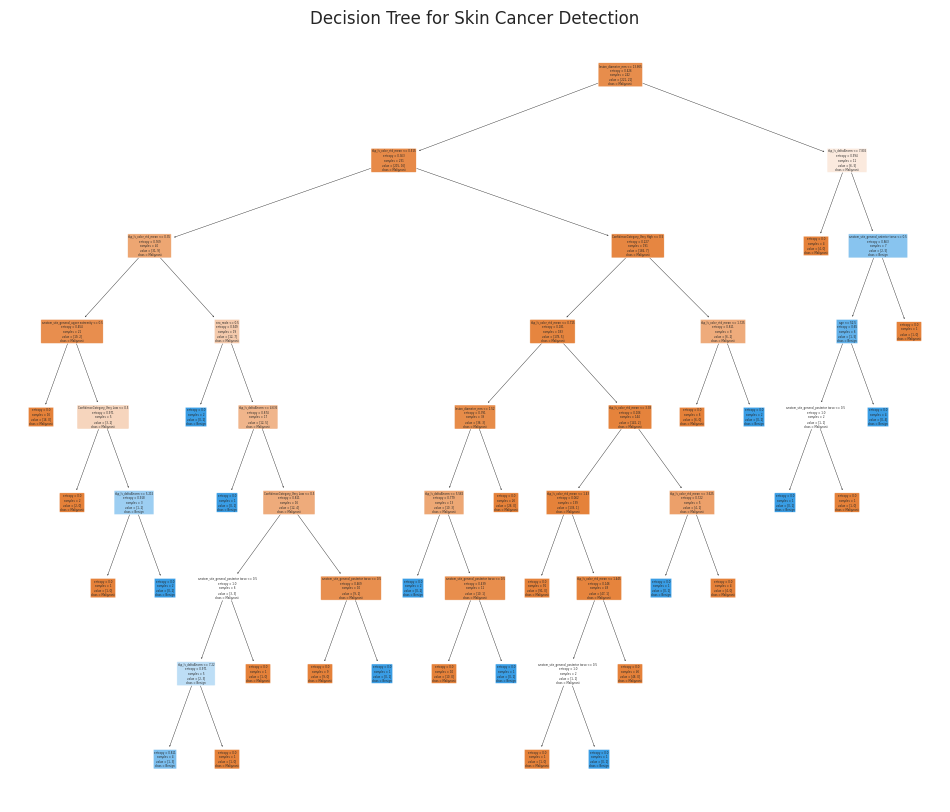

In [231]:
# plotting decision tree model
from sklearn import tree 
import matplotlib.pyplot as plt
plt.figure(figsize=(12,10))
tree.plot_tree(dt_model, 
               feature_names=X_train.columns.tolist(),
               class_names=['Malignant', 'Benign'],
               filled=True, 
               rounded=True)
plt.title("Decision Tree for Skin Cancer Detection")
plt.savefig('decision_tree_visualization.png', dpi=300, bbox_inches='tight')
plt.show()